In [1]:
modisco_file = "output/nexus,gw,1,1,1,FALSE,valid,0.5,64,25,0.004,9,/deeplift/all/out/profile/wn/modisco.h5"

In [2]:
# Parameters
modisco_file = "/workdir/shl4034/class_project/RA_disease_model/8ba4f11f-2186-4011-b449-d8a0a7d2e694/modisco/RA_disease/modisco.h5"
modisco_dir = "/workdir/shl4034/class_project/RA_disease_model/8ba4f11f-2186-4011-b449-d8a0a7d2e694/modisco/RA_disease"


## Results

In [3]:
# Imports
from bpnet.modisco.files import ModiscoFile
import numpy as np
import pandas as pd
from plotnine import *
import matplotlib.pyplot as plt
%matplotlib inline

/workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/requests/__init__.py:104: RequestsDependencyWarning: urllib3 (1.26.20) or chardet (5.0.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  RequestsDependencyWarning)


Using TensorFlow backend.


/workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/workdir/shl4034/miniconda3/envs/b

/workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/tensorboard/compat/tensorflow_stub/dtypes.py:541: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/tensorboard/compat/tensorflow_stub/dtypes.py:542: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/tensorboard/compat/tensorflow_stub/dtypes.py:543: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/workdir/shl4

2025-04-07 00:46:45,645 [WARNING] From /workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.



/workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/bpnet/plot/heatmaps.py:6: MatplotlibDeprecationWarning: 
The mpl_toolkits.axes_grid1.colorbar module was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use matplotlib.colorbar instead.
  from mpl_toolkits.axes_grid1.colorbar import colorbar


In [4]:
mf = ModiscoFile(modisco_file)

## Numbers

In [5]:
stats = mf.stats()
stats

TF-MoDISco is using the TensorFlow backend.


# seqlets assigned to patterns: 18376 / 747038 (2%)


{'patterns': 11,
 'clustered_seqlets': 18376,
 'metaclusters': 1,
 'all_seqlets': 747038,
 'clustered_seqlets_frac': 0.024598480934035483}

## Plot patterns

# seqlets assigned to patterns: 18376 / 747038 (2%)


/workdir/shl4034/miniconda3/envs/bpnet/lib/python3.6/site-packages/descartes/patch.py:65: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.


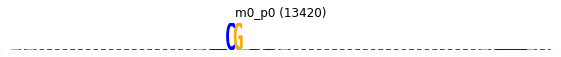

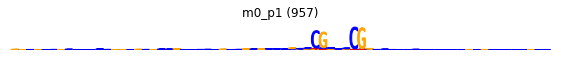

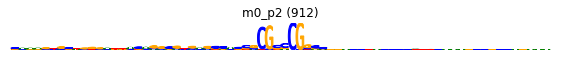

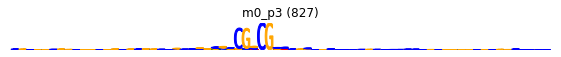

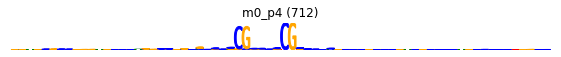

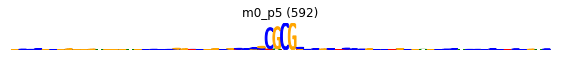

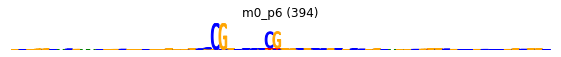

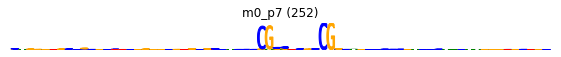

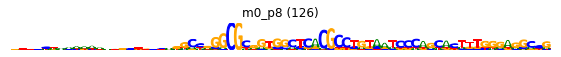

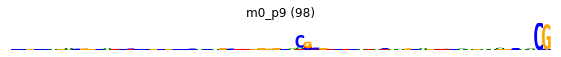

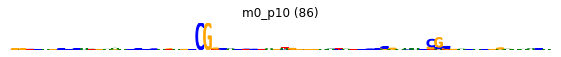

In [6]:
mf.plot_all_patterns(trim_frac=0, letter_width=0.14, height=0.5, ylim=[0, 2], no_axis=True)

## Important tasks per metacluster

In [7]:
mc_stat = mf.metacluster_stats()

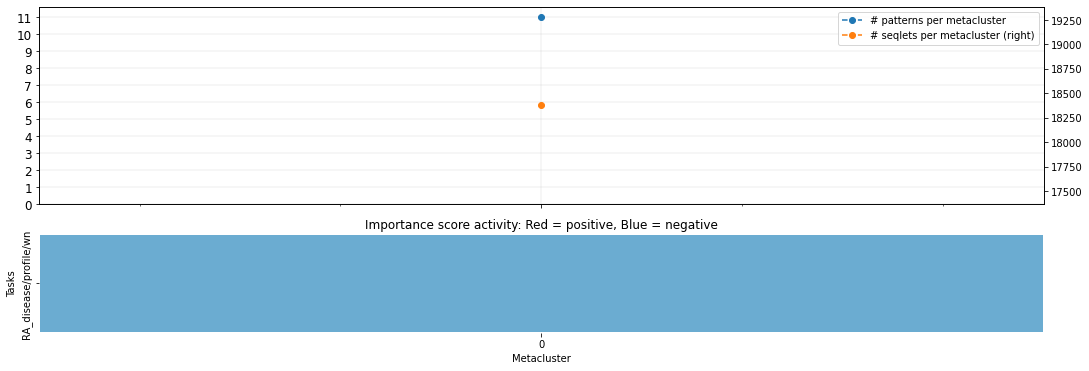

In [8]:
mcs_grouped = mc_stat.groupby("metacluster").n.agg(["count", "sum"]).reset_index()
if len(mc_stat) > 0 and not mcs_grouped['count'].isnull().any():
    fig, ax = plt.subplots(2, 1, sharex=False, figsize=(18,6), 
                           gridspec_kw={'height_ratios': [2,1]})
    mcs_grouped.plot("metacluster", "count", 
                     label="# patterns per metacluster", style="o--", 
                     ax=ax[0], 
                     yticks=range(int(mcs_grouped['count'].max()+1)),
                     xticks=range(38),
                     fontsize='large',
                     xlim=(-.5, len(mf.metaclusters()) - .5 ))
    mcs_grouped.plot("metacluster", "sum", 
                     label="# seqlets per metacluster", 
                     style="o--", ax=ax[0], secondary_y=True)
    ax[0].grid(linewidth=0.2)
    mf.plot_metacluster_activity(ax[1], cbar=False)
    ax[1].set_title("Importance score activity: Red = positive, Blue = negative");
else:
    print("Some counts were none")

Metaclusters heatmap


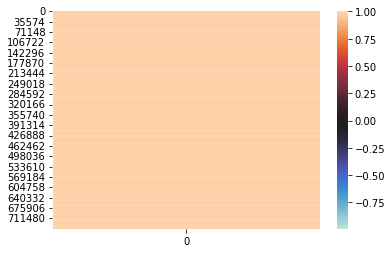

In [9]:
print("Metaclusters heatmap")
import seaborn as sns
activity_patterns = np.array(mf.f.f['metaclustering_results']['attribute_vectors'])[
                    np.array(
        [x[0] for x in sorted(
                enumerate(mf.f.f['metaclustering_results']['metacluster_indices']),
               key=lambda x: x[1])])]
sns.heatmap(activity_patterns, center=0);